# M7 Assignment 1
Neural Networks

Context:
Hospital readmission is a major challenge in healthcare because repeated admissions increase treatment costs and indicate gaps in patient care or follow-up. Hospitals aim to identify high-risk patients early so that preventive measures such as closer monitoring, medication review, and scheduled follow-ups can be implemented.

## Dataset Description

* id: Unique identifier assigned to each patient.
* age: Age group of the patient, represented as categorical intervals (e.g., 50–60, 60–70).
* time_in_hospital: Number of days the patient stayed in the hospital during the current visit.
* n_lab_procedures: Total number of laboratory tests conducted during the visit.
* n_procedures: Number of medical procedures performed on the patient.
* n_medications: Total number of medications prescribed.
* n_outpatient: Number of outpatient visits the patient had prior to this admission.
* n_inpatient: Number of previous inpatient admissions.
* n_emergency: Number of emergency visits made by the patient in the past.
* diagnosis: Primary diagnosis category of the patient (e.g., Circulatory, Injury, Digestive, etc.).
* glucose_test: Result of the glucose test (e.g., normal, high, or no test conducted).
* A1Ctest: Indicates the result/status of the Hemoglobin A1C test.
* change: Indicates whether there was a change in medication during the hospital stay (yes/no).
* diabetes_med: Indicates whether the patient is on diabetes medication (yes/no).
* readmitted: Target variable indicating whether the patient was readmitted to the hospital (yes/no).

Questions:

1. Import the dataset, perform data preprocessing (create dummy variables and standardize numeric features), split into training and test sets, and convert the data into PyTorch tensors.
2. Implement Neural Networks with one hidden layer (4 neurons)
3. Modify the solution above with one hidden layer and 16 neurons
4. Add a hidden layer- first with 16 neurons and second with 8 neurons
5. Compare three models using ROC curves and AUC scores.

In [14]:
import warnings
warnings.filterwarnings("ignore")

In [15]:
import pandas as pd

df = pd.read_csv("Hospital Readmissions.csv")
df.head()

,id,age,time_in_hospital,n_lab_procedures,n_procedures,n_medications,n_outpatient,n_inpatient,n_emergency,diagnosis,glucose_test,A1Ctest,change,diabetes_med,readmitted
0,1,[70-80),8,72,1,18,2,0,0,Circulatory,no,no,no,yes,no
1,2,[70-80),3,34,2,13,0,0,0,Other,no,no,no,yes,no
2,3,[50-60),5,45,0,18,0,0,0,Circulatory,no,no,yes,yes,yes
3,4,[70-80),2,36,0,12,1,0,0,Circulatory,no,no,yes,yes,yes
4,5,[60-70),1,42,0,7,0,0,0,Other,no,no,no,yes,no


In [16]:
df.dtypes

id                   int64
age                 object
time_in_hospital     int64
n_lab_procedures     int64
n_procedures         int64
n_medications        int64
n_outpatient         int64
n_inpatient          int64
n_emergency          int64
diagnosis           object
glucose_test        object
A1Ctest             object
change              object
diabetes_med        object
readmitted          object
dtype: object

In [17]:
df.describe().round(2)

,id,time_in_hospital,n_lab_procedures,n_procedures,n_medications,n_outpatient,n_inpatient,n_emergency
count,25000.00,25000.00,25000.00,25000.00,25000.00,25000.00,25000.00,25000.00
mean,12500.50,4.45,43.24,1.35,16.25,0.37,0.62,0.19
std,7217.02,3.00,19.82,1.72,8.06,1.20,1.18,0.89
min,1.00,1.00,1.00,0.00,1.00,0.00,0.00,0.00
25%,6250.75,2.00,31.00,0.00,11.00,0.00,0.00,0.00
50%,12500.50,4.00,44.00,1.00,15.00,0.00,0.00,0.00
75%,18750.25,6.00,57.00,2.00,20.00,0.00,1.00,0.00
max,25000.00,14.00,113.00,6.00,79.00,33.00,15.00,64.00


In [18]:
df.isnull().sum()

id                  0
age                 0
time_in_hospital    0
n_lab_procedures    0
n_procedures        0
n_medications       0
n_outpatient        0
n_inpatient         0
n_emergency         0
diagnosis           0
glucose_test        0
A1Ctest             0
change              0
diabetes_med        0
readmitted          0
dtype: int64

## Import Libraries

The following libraries follow the same neural-network workflow used in the M7U4 class notebook.

In [19]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from skorch import NeuralNetClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

In [20]:
# Set seeds for reproducibility
torch.manual_seed(1)
np.random.seed(42)

## Preprocessing

Create the target variable, split the data into train and test sets, standardize numeric variables, and create dummy variables for categorical features.

In [21]:
X = df.drop(['id', 'readmitted'], axis=1)
y = df['readmitted'].map({'no': 0, 'yes': 1})

# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [22]:
# Standardize numeric variables using only the training data
numeric_cols = [
    'time_in_hospital', 'n_lab_procedures', 'n_procedures', 'n_medications',
    'n_outpatient', 'n_inpatient', 'n_emergency'
]

scaler = StandardScaler()
X_train = X_train.copy()
X_test = X_test.copy()
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

# Create dummy variables for categorical columns
categorical_cols = ['age', 'diagnosis', 'glucose_test', 'A1Ctest', 'change', 'diabetes_med']
X_train = pd.get_dummies(X_train, columns=categorical_cols, drop_first=True)
X_test = pd.get_dummies(X_test, columns=categorical_cols, drop_first=True)

# Align test columns with train columns
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

# Convert everything to numeric values for PyTorch
X_train = X_train.astype(float)
X_test = X_test.astype(float)

print('X_train shape:', X_train.shape)
print('X_test shape:', X_test.shape)
print('y_train shape:', y_train.shape)
print('y_test shape:', y_test.shape)

X_train shape: (20000, 25)
X_test shape: (5000, 25)
y_train shape: (20000,)
y_test shape: (5000,)


## Convert to PyTorch Tensors

The neural network receives the features as `float32` tensors and the binary target as a single-column `float32` tensor.

In [23]:
X_train_t = torch.tensor(X_train.values, dtype=torch.float32)
X_test_t = torch.tensor(X_test.values, dtype=torch.float32)
y_train_t = torch.tensor(y_train.values, dtype=torch.float32).unsqueeze(1)
y_test_t = torch.tensor(y_test.values, dtype=torch.float32).unsqueeze(1)

## Class Balance Check

In [24]:
counts = df['readmitted'].value_counts().reset_index()
counts.columns = ['readmitted', 'Freq']
counts['Percent'] = counts['Freq'] / counts['Freq'].sum()
counts

,readmitted,Freq,Percent
0,no,13246,0.52984
1,yes,11754,0.47016


## Define and Train the Neural Networks

Three feedforward neural networks are trained: one simple model with 4 neurons, one wider model with 16 neurons, and one deeper model with two hidden layers of 16 and 8 neurons.

In [25]:
input_dim = X_train_t.shape[1]
input_dim

25

### 1. Model with 4 Neurons

In [26]:
model_4 = NeuralNetClassifier(
    module=nn.Sequential(
        nn.Linear(input_dim, 4),
        nn.ReLU(),
        nn.Linear(4, 1)
    ),
    max_epochs=100,
    optimizer=optim.Adam,
    criterion=nn.BCEWithLogitsLoss,
    batch_size=32,
    verbose=0
)

model_4.fit(X_train_t, y_train_t)

<class 'skorch.classifier.NeuralNetClassifier'>[initialized](
  module_=Sequential(
    (0): Linear(in_features=25, out_features=4, bias=True)
    (1): ReLU()
    (2): Linear(in_features=4, out_features=1, bias=True)
  ),
)

### 2. Model with 16 Neurons

In [27]:
model_16 = NeuralNetClassifier(
    module=nn.Sequential(
        nn.Linear(input_dim, 16),
        nn.ReLU(),
        nn.Linear(16, 1)
    ),
    max_epochs=100,
    optimizer=optim.Adam,
    criterion=nn.BCEWithLogitsLoss,
    batch_size=32,
    verbose=0
)

model_16.fit(X_train_t, y_train_t)

<class 'skorch.classifier.NeuralNetClassifier'>[initialized](
  module_=Sequential(
    (0): Linear(in_features=25, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=1, bias=True)
  ),
)

### 3. Model with Two Hidden Layers: 16 and 8 Neurons

In [28]:
model_16_8 = NeuralNetClassifier(
    module=nn.Sequential(
        nn.Linear(input_dim, 16),
        nn.ReLU(),
        nn.Linear(16, 8),
        nn.ReLU(),
        nn.Linear(8, 1)
    ),
    max_epochs=100,
    optimizer=optim.Adam,
    criterion=nn.BCEWithLogitsLoss,
    batch_size=32,
    verbose=0
)

model_16_8.fit(X_train_t, y_train_t)

<class 'skorch.classifier.NeuralNetClassifier'>[initialized](
  module_=Sequential(
    (0): Linear(in_features=25, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=8, bias=True)
    (3): ReLU()
    (4): Linear(in_features=8, out_features=1, bias=True)
  ),
)

## Model Evaluation

In [29]:
def evaluate_model(model, X_test_t, y_test_t):
    y_probs = model.predict_proba(X_test_t)[:, 1]
    y_pred = (y_probs > 0.5).astype(int)
    y_true = y_test_t.numpy().ravel()

    print('Classification Report:\n')
    print(classification_report(y_true, y_pred, target_names=['no', 'yes']))

    auc = roc_auc_score(y_true, y_probs)
    print('AUC Score:', round(auc, 4))

    return auc

In [30]:
auc_4 = evaluate_model(model_4, X_test_t, y_test_t)

Classification Report:

              precision    recall  f1-score   support

          no       0.61      0.72      0.66      2649
         yes       0.61      0.49      0.54      2351

    accuracy                           0.61      5000
   macro avg       0.61      0.61      0.60      5000
weighted avg       0.61      0.61      0.61      5000

AUC Score: 0.6527


In [31]:
auc_16 = evaluate_model(model_16, X_test_t, y_test_t)

Classification Report:

              precision    recall  f1-score   support

          no       0.61      0.68      0.65      2649
         yes       0.59      0.51      0.55      2351

    accuracy                           0.60      5000
   macro avg       0.60      0.60      0.60      5000
weighted avg       0.60      0.60      0.60      5000

AUC Score: 0.6417


In [32]:
auc_16_8 = evaluate_model(model_16_8, X_test_t, y_test_t)

Classification Report:

              precision    recall  f1-score   support

          no       0.62      0.68      0.65      2649
         yes       0.60      0.53      0.56      2351

    accuracy                           0.61      5000
   macro avg       0.61      0.61      0.61      5000
weighted avg       0.61      0.61      0.61      5000

AUC Score: 0.6385


## ROC Curve Comparison

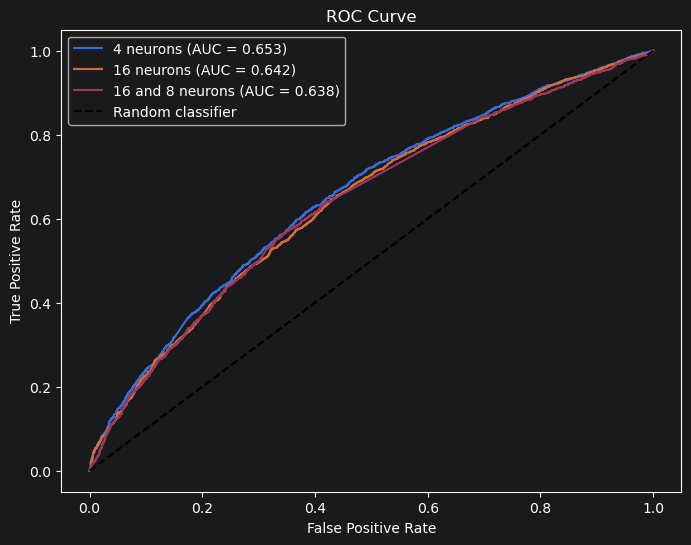

In [33]:
def plot_roc(model, X_test_t, y_test_t, title):
    y_probs = model.predict_proba(X_test_t)[:, 1]
    y_true = y_test_t.numpy().ravel()
    fpr, tpr, _ = roc_curve(y_true, y_probs)
    auc_score = roc_auc_score(y_true, y_probs)

    plt.plot(fpr, tpr, label=f'{title} (AUC = {auc_score:.3f})')

plt.figure(figsize=(8, 6))
plot_roc(model_4, X_test_t, y_test_t, '4 neurons')
plot_roc(model_16, X_test_t, y_test_t, '16 neurons')
plot_roc(model_16_8, X_test_t, y_test_t, '16 and 8 neurons')
plt.plot([0, 1], [0, 1], 'k--', label='Random classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

## Conclusion

The model with 4 neurons produced the highest AUC score in this run (approximately 0.653), followed by the 16-neuron model and the two-hidden-layer model. Although the larger models have more capacity, they did not improve test-set AUC here. Based on these results, the 4-neuron model is the preferred option because it gives the best ROC/AUC performance while keeping the architecture simpler.